# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

# Student Answers

So for this, I used reviews from a resutrant to show what words customers mention most, and if those common words would be posiitve or negative and how the text aligns with the star rating they gave the resutrant. 

Data set 

Review -- Rating 
- 'Amazing food and friendly staff! Highly recommend the tacos.', -- 5 stars
- 'Service was slow, and my soup was cold. Not coming back.', -- 2 stars
- 'Great vibe, decent prices, and the burger was excellent.', --4 stars
- 'Mediocre experience. The pasta lacked flavor.', -- 3 stars
- 'Best pizza in town! Crispy crust and fresh toppings.', -- 5 stars
- 'Terrible service. Waited 40 minutes for appetizers.', -- 1 stars
- 'Loved the desserts—especially the cheesecake. Will return soon!', -- 5 stars
- 'Okay place. Portions small for the price.', -- 3 stars
- 'Fantastic brunch spot. Coffee and omelette were perfect.', -- 5 stars
- 'Disappointing. Overcooked steak and noisy environment.' -- 2 stars


In [2]:
# Setting up the data 
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

try:
    from wordcloud import WordCloud
    _WC_OK = True
except:
    _WC_OK = False

try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    nltk.download('vader_lexicon')
    sia = SentimentIntensityAnalyzer()
except:
    sia = None

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 140

# Demo dataset
reviews = pd.DataFrame({
    'text': [
        'Amazing food and friendly staff! Highly recommend the tacos.',
        'Service was slow, and my soup was cold. Not coming back.',
        'Great vibe, decent prices, and the burger was excellent.',
        'Mediocre experience. The pasta lacked flavor.',
        'Best pizza in town! Crispy crust and fresh toppings.',
        'Terrible service. Waited 40 minutes for appetizers.',
        'Loved the desserts—especially the cheesecake. Will return soon!',
        'Okay place. Portions small for the price.',
        'Fantastic brunch spot. Coffee and omelette were perfect.',
        'Disappointing. Overcooked steak and noisy environment.'
    ],
    'stars': [5,2,4,3,5,1,5,3,5,2]
})
reviews.head()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kilgo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,text,stars
0,Amazing food and friendly staff! Highly recomm...,5
1,"Service was slow, and my soup was cold. Not co...",2
2,"Great vibe, decent prices, and the burger was ...",4
3,Mediocre experience. The pasta lacked flavor.,3
4,Best pizza in town! Crispy crust and fresh top...,5


In [3]:
# Now we will remove all of the filler words that have no meaning. 
fillerwords = set("a an the is are was were be been being i me my we our you your he she it they them this that to for of on in with at by from as and or if then but not no so too very just really".split())

def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    return [t for t in text.split() if t and t not in fillerwords]

reviews['tokens'] = reviews['text'].apply(tokenize)
reviews[['text','tokens']].head()


,text,tokens
0,Amazing food and friendly staff! Highly recomm...,"[amazing, food, friendly, staff, highly, recom..."
1,"Service was slow, and my soup was cold. Not co...","[service, slow, soup, cold, coming, back]"
2,"Great vibe, decent prices, and the burger was ...","[great, vibe, decent, prices, burger, excellent]"
3,Mediocre experience. The pasta lacked flavor.,"[mediocre, experience, pasta, lacked, flavor]"
4,Best pizza in town! Crispy crust and fresh top...,"[best, pizza, town, crispy, crust, fresh, topp..."


# Visualization 1 : Word Frequency in Reviews 

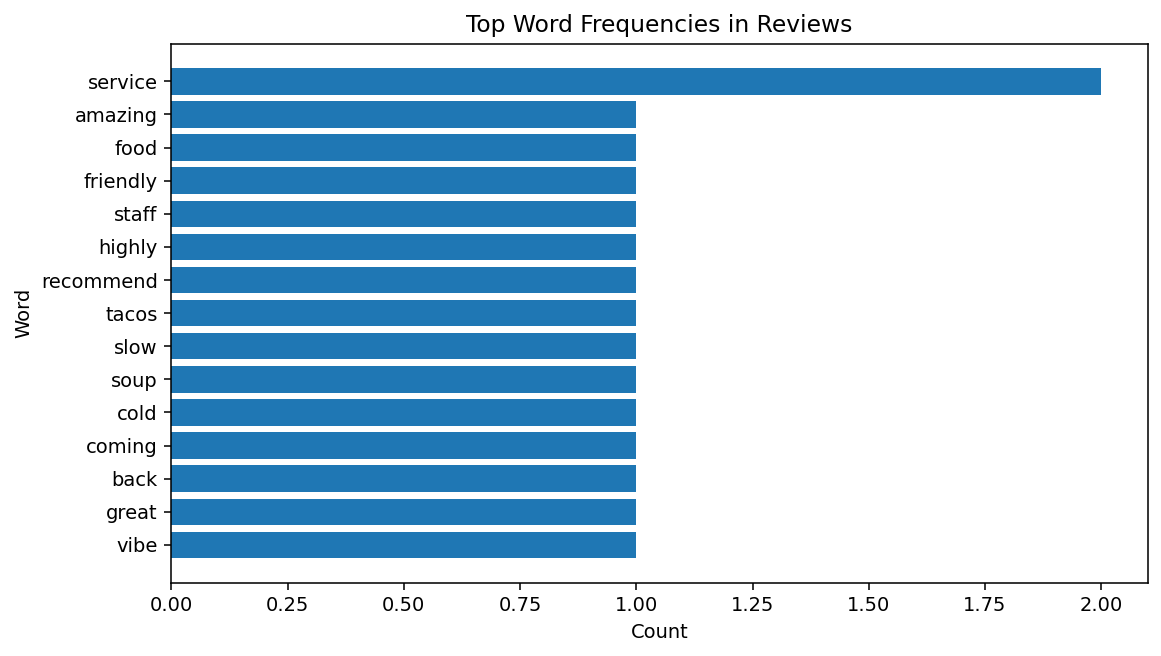

In [4]:
all_tokens = [t for row in reviews['tokens'] for t in row]
freqs = Counter(all_tokens)
top_n = 15
words, counts = zip(*freqs.most_common(top_n))

plt.barh(words[::-1], counts[::-1])
plt.title("Top Word Frequencies in Reviews")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()


# What this shows? 

This bar chart shows the 15 most frequent words across all of the reviews given. It seem that words like service, food, and great appear often, which suggests that customers mainly comment on service quality and food in the reviews. 

# Visualization 2: A word cloud

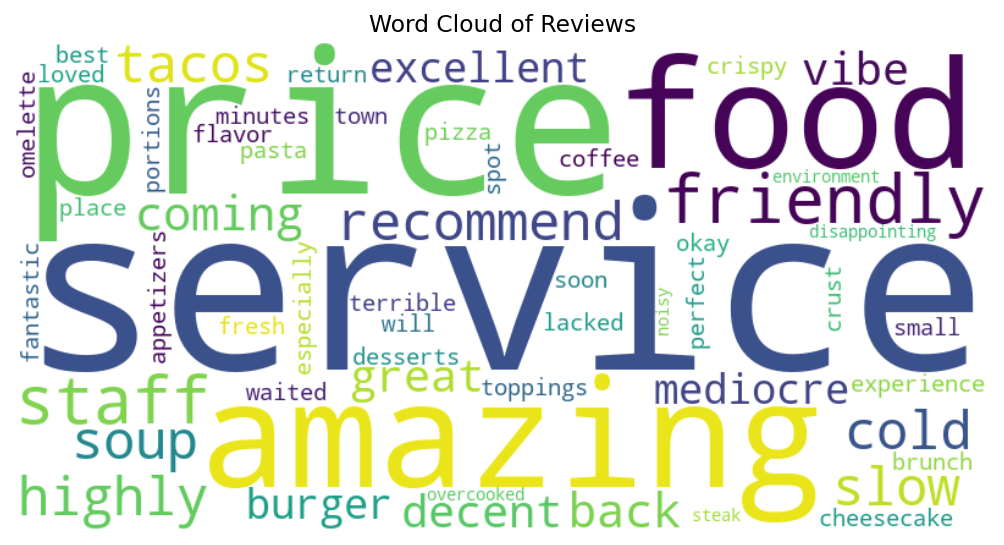

In [5]:
if _WC_OK:
    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate(' '.join(all_tokens))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud of Reviews")
    plt.show()
else:
    print("WordCloud not installed — skipping this visualization.")


# What does this show? 


This graphic showcases the most frequently used terms in the reviews. It seems that words like amazing, best, and fantastic showed more and indicates that majority of the reviews have a most favorable tone. You can easily look at this visualization to show the power of each word across the reviews. 

# Visualization 3 Do the words customers give match up with the rating? 

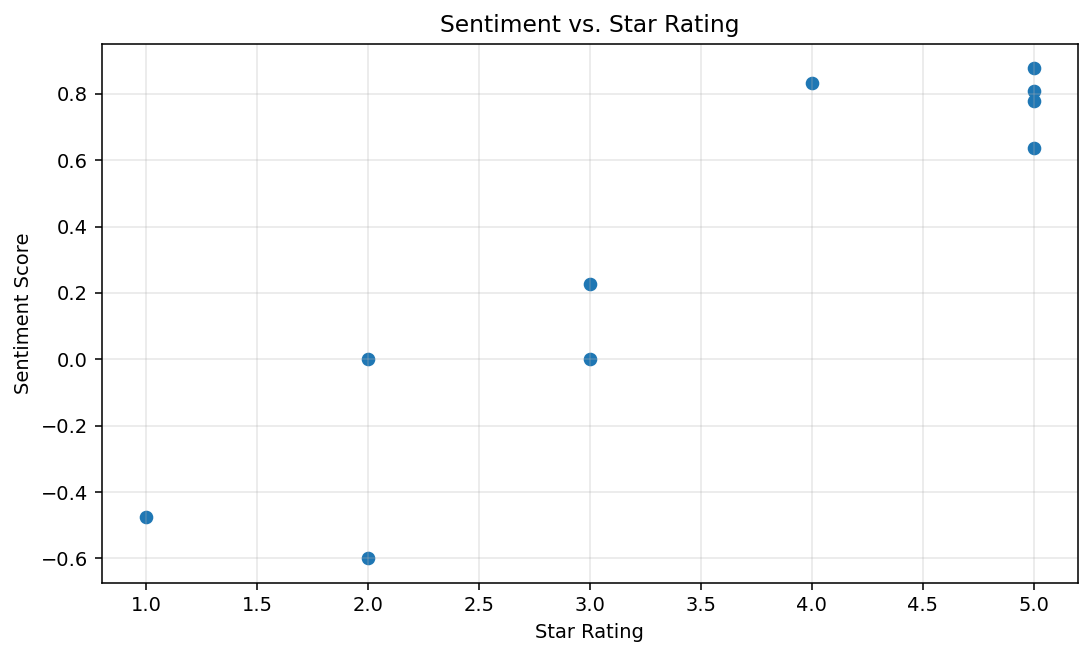

In [6]:
def get_sentiment(text):
    if sia:
        return sia.polarity_scores(text)['compound']
    # fallback naive
    pos_words = {'amazing','great','excellent','best','friendly','love','fantastic','perfect','recommend','fresh'}
    neg_words = {'terrible','slow','cold','mediocre','disappointing','overcooked','noisy','not'}
    toks = set(tokenize(text))
    return sum(1 for w in toks if w in pos_words) - sum(1 for w in toks if w in neg_words)

reviews['sentiment'] = reviews['text'].apply(get_sentiment)

plt.scatter(reviews['stars'], reviews['sentiment'])
plt.title("Sentiment vs. Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Sentiment Score")
plt.grid(True, alpha=0.3)
plt.show()


# What does this mean? 
We do see a postiive trend with reviews that show higher scores correspond to higher ratings further validating that the reviews aligns with the actual ratings. (EX no one gave a negative review and 5 stars and vice versa no one gave a 1 star review with positive meanings. 